In [1]:
# output folder, dist type, optional parameter for dist type

import sys
import os
import torch

cwd = os.getcwd()
root = cwd.split("BernsteinMartingaleNet")[0] + "BernsteinMartingaleNet"
if root not in sys.path:
    sys.path.append(root)

from lib.utils import train_model, get_full_sequence_data_by_day
from lib.BLogistic import BLogistic, MixedBLogistic
from lib.DistHead import NormalHead, StudentTHead, SkewedStudentTHead
from lib.Michenkow import MichenkowManytoMany
assert torch.cuda.is_available()
device = torch.device('cuda')

In [2]:

dist_type  = "StudentT"
dist_param = ""
output_folder =  root + f"/MichenkowResults/{dist_type}NoReg_NoRV/"

In [3]:

dist_head = None
if dist_type == "Normal":
    dist_head = NormalHead(device)
elif dist_type == "StudentT":
    dist_head = StudentTHead(device)
elif dist_type == "SkewedStudentT":
    dist_head = SkewedStudentTHead(device)
elif dist_type == "BLogistic":
    if dist_param == "":
        raise ValueError("BLogistic dist type requires a degree parameter")
    dof = int(dist_param)
    dist_head = BLogistic(dof - 2, device)
elif dist_type == "MixedBLogistic":
    if dist_param == "":
        raise ValueError("MixedBLogistic dist type requires a degree parameter")
    dof = int(dist_param)
    dist_head = MixedBLogistic(dof, device)
else:
    raise ValueError(f"Invalid dist type: {dist_type}")

folder_path = root + "/MarketData/historical_data"

In [4]:
train, dev, test = get_full_sequence_data_by_day(folder_path, 0.2, 0.2, force_recompute=True)
print("train", train.shape)
print("dev", dev.shape)
print("test", test.shape)


skipping 2020-11-27
skipping 2020-12-24
skipping 2021-11-26
skipping 2022-11-25
skipping 2023-07-03
skipping 2023-11-24
skipping 2024-07-03
skipping 2024-11-29
skipping 2024-12-24
skipping 2025-07-03
train (748, 391, 3)
dev (249, 391, 3)
test (249, 391, 3)


In [5]:

train = torch.tensor(train, device=device)
dev = torch.tensor(dev, device=device)
test = torch.tensor(test, device=device)

train_xs = train[:, :-1, 0:1]
dev_xs = dev[:, :-1, 0:1]
test_xs = test[:, :-1, 0:1]

train_ys = train[:, 1:, 1]
dev_ys = dev[:, 1:, 1]
test_ys = test[:, 1:, 1]

std_x = torch.sqrt((train_xs**2).mean(dim=(0, 1)))  # Shape: (2,)
mean_x = train_xs.mean(dim=(0, 1))

print("std x:", std_x)
print("mean_x:", mean_x)

std_y = torch.sqrt((train_ys**2).mean(dim=(0, 1)))  # Shape: (2,)
mean_y = train_ys.mean(dim=(0, 1))

print("std y:", std_y)
print("mean y:", mean_y)

train_xs = (train_xs-mean_x) / std_x
dev_xs = (dev_xs-mean_x) / std_x
test_xs = (test_xs-mean_x) / std_x
train_ys = (train_ys-mean_y) / std_y
dev_ys = (dev_ys-mean_y) / std_y
test_ys = (test_ys-mean_y) / std_y

print("X train:", train_xs.shape, "y train", train_ys.shape)
print("X dev:", dev_xs.shape, "y dev", dev_ys.shape)
print("X test:", test_xs.shape, "y test", test_ys.shape)



std x: tensor([0.0004], device='cuda:0')
mean_x: tensor([-2.3330e-07], device='cuda:0')
std y: tensor(5.1853e-07, device='cuda:0')
mean y: tensor(1.7846e-07, device='cuda:0')
X train: torch.Size([748, 390, 1]) y train torch.Size([748, 390])
X dev: torch.Size([249, 390, 1]) y dev torch.Size([249, 390])
X test: torch.Size([249, 390, 1]) y test torch.Size([249, 390])


In [6]:

train = torch.tensor(train, device=device)
dev = torch.tensor(dev, device=device)
test = torch.tensor(test, device=device)

train_xs = train[:, :-1, 0:1]
dev_xs = dev[:, :-1, 0:1]
test_xs = test[:, :-1, 0:1]

train_ys = train[:, 1:, 0]
dev_ys = dev[:, 1:, 0]
test_ys = test[:, 1:, 0]

std_x = torch.sqrt((train_xs**2).mean(dim=(0, 1)))  # Shape: (2,)
mean_x = train_xs.mean(dim=(0, 1))

print("std x:", std_x)
print("mean_x:", mean_x)

std_y = torch.sqrt((train_ys**2).mean(dim=(0, 1)))  # Shape: (2,)
mean_y = train_ys.mean(dim=(0, 1))

print("std y:", std_y)
print("mean y:", mean_y)

train_xs = (train_xs-mean_x) / std_x
dev_xs = (dev_xs-mean_x) / std_x
test_xs = (test_xs-mean_x) / std_x
train_ys = (train_ys-mean_y) / std_y
dev_ys = (dev_ys-mean_y) / std_y
test_ys = (test_ys-mean_y) / std_y

print("X train:", train_xs.shape, "y train", train_ys.shape)
print("X dev:", dev_xs.shape, "y dev", dev_ys.shape)
print("X test:", test_xs.shape, "y test", test_ys.shape)



std x: tensor([0.0004], device='cuda:0')
mean_x: tensor([-2.3330e-07], device='cuda:0')
std y: tensor(0.0004, device='cuda:0')
mean y: tensor(-2.1644e-07, device='cuda:0')
X train: torch.Size([748, 390, 1]) y train torch.Size([748, 390])
X dev: torch.Size([249, 390, 1]) y dev torch.Size([249, 390])
X test: torch.Size([249, 390, 1]) y test torch.Size([249, 390])


C:\Users\MainUser\AppData\Local\Temp\ipykernel_43728\426480493.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train = torch.tensor(train, device=device)
C:\Users\MainUser\AppData\Local\Temp\ipykernel_43728\426480493.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev = torch.tensor(dev, device=device)
C:\Users\MainUser\AppData\Local\Temp\ipykernel_43728\426480493.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test = torch.tensor(test, device=device)


In [7]:
lr = 0.002
decay_step = 200
decay_gamma = 0.5
weight_decay = 0
weight_decay = 0.000
num_steps = 400 + 1
batch_size = 1024


In [8]:

m2m_model = MichenkowManytoMany(dist_head, device, feature_size=1)

model, train_losses, dev_losses = train_model(m2m_model,
                                              train_xs, train_ys, dev_xs, dev_ys, test_xs,test_ys, lr, weight_decay, num_steps, batch_size=batch_size, device=device, output_folder=output_folder, lr_decay_step=decay_step, lr_decay_gamma=decay_gamma)



Initializing LSTM with dist=StudentTHead, dof=2
num batches 0
Init, Train Loss: 1.3060, Dev Loss: 1.3197, Dev Loss confidence interval: 1.3144, 1.3249
Step 0, Train Loss: 1.3045, Dev Loss: 1.3182, Dev Loss confidence interval: 1.3130, 1.3235, LR: 0.002000
Step 10, Train Loss: 1.2538, Dev Loss: 1.2737, Dev Loss confidence interval: 1.2668, 1.2806, LR: 0.002000
Step 20, Train Loss: 1.2524, Dev Loss: 1.2715, Dev Loss confidence interval: 1.2647, 1.2783, LR: 0.002000
Step 30, Train Loss: 1.2502, Dev Loss: 1.2694, Dev Loss confidence interval: 1.2625, 1.2764, LR: 0.002000
Step 40, Train Loss: 1.2385, Dev Loss: 1.2618, Dev Loss confidence interval: 1.2550, 1.2685, LR: 0.002000
Step 50, Train Loss: 1.2385, Dev Loss: 1.2559, Dev Loss confidence interval: 1.2491, 1.2626, LR: 0.002000
Step 60, Train Loss: 1.2501, Dev Loss: 1.2699, Dev Loss confidence interval: 1.2626, 1.2771, LR: 0.002000
Step 70, Train Loss: 1.2494, Dev Loss: 1.2685, Dev Loss confidence interval: 1.2614, 1.2755, LR: 0.002000
S

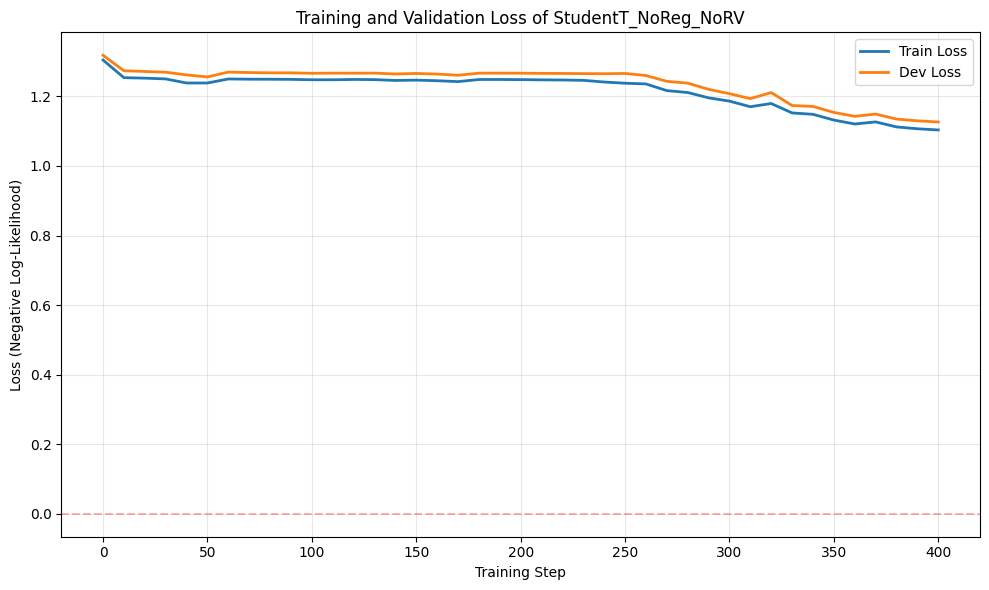

In [9]:
import matplotlib.pyplot as plt
import numpy as np

steps = np.arange(0, len(train_losses) * 10, 10)  # Since you log every 10 steps

plt.figure(figsize=(10, 6))
plt.plot(steps, train_losses, label='Train Loss', linewidth=2)
plt.plot(steps, dev_losses, label='Dev Loss', linewidth=2)
plt.xlabel('Training Step')
plt.ylabel('Loss (Negative Log-Likelihood)')
plt.title(f"Training and Validation Loss of {dist_type}_NoReg_NoRV")
plt.legend()
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()